In [1]:
import os
import numpy as np
import pandas as pd
from scipy import signal
from matplotlib import pyplot as plt
from scipy.stats import kurtosis, skew
# from biosppy.signals import ecg
from tqdm import tqdm
import wfdb
from scipy.signal import welch
# import seaborn as sns
import neurokit2 as nk
import networkx as nx
# import igraph as ig
import itertools
from tqdm import tqdm
from scipy.signal import resample
import hrvanalysis as hrv
from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.analysis_type import Classic
from pyrqa.neighbourhood import FixedRadius
from pyrqa.metric import EuclideanMetric
from pyrqa.computation import RQAComputation
from pyrqa.computation import RPComputation
from pyrqa.image_generator import ImageGenerator
plt.rcdefaults()

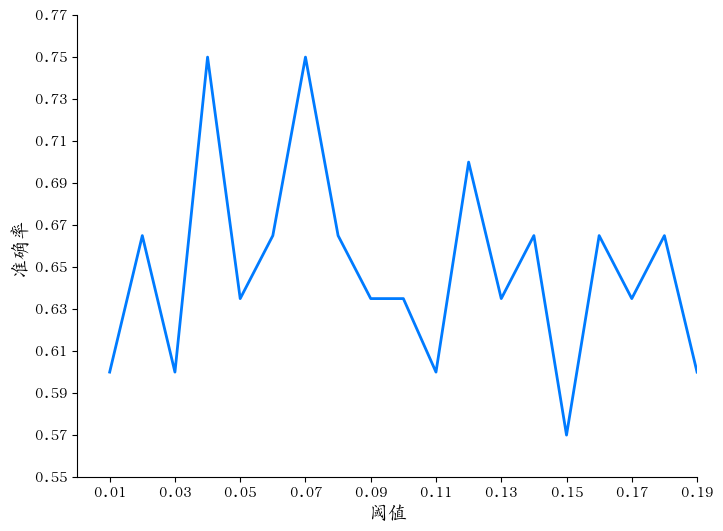

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 假设已有数据
# 这里模拟生成示例数据，实际使用时请替换为真实数据
x = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19])
y = np.array([0.6, 0.665, 0.6, 0.75, 0.635, 0.665, 0.75, 0.665, 0.635, 0.635, 0.6, 0.7, 0.635, 0.665, 0.57, 0.665, 0.635, 0.665, 0.6])

# 1. 设置字体
plt.rcParams['font.sans-serif'] = ['AR PL UKai CN']  # 设置中文字体为黑体，可按需更换
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 2. 创建画布和子图
fig, ax = plt.subplots(figsize=(8, 6))  # 调整画布大小

# 3. 绘制折线图并设置样式
line, = ax.plot(x, y, color='#007BFF', linewidth=2.0, linestyle='-')  # 调整颜色、线宽和线型
# 可以添加标记，比如圆点
# line, = ax.plot(x, y, color='#007BFF', linewidth=2.0, linestyle='-', marker='o') 

# 4. 设置坐标轴标签和标题
ax.set_xlabel('阈值', fontsize=14)  # 增大字体大小
ax.set_ylabel('准确率', fontsize=14)
# ax.set_title('不同阈值下的准确率变化', fontsize=16)  # 添加标题

# 5. 调整坐标轴刻度和范围
ax.set_xlim(min(x)-0.01, max(x))  # 设置x轴范围
ax.set_ylim(min(y) - 0.02, max(y) + 0.02)  # 适当扩展y轴范围
ax.set_xticks(np.arange(min(x), max(x) + 0.02, 0.02))  # 调整x轴刻度间隔
ax.set_yticks(np.arange(min(y) - 0.02, max(y) + 0.02, 0.02))  # 调整y轴刻度间隔
ax.tick_params(axis='both', which='major', labelsize=12)  # 设置刻度标签字体大小

# # 6. 添加网格线
# ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)  # 调整网格线样式

# 7. 美化边框
ax.spines['top'].set_visible(False)  # 隐藏上边框
ax.spines['right'].set_visible(False)  # 隐藏右边框

# 8. 保存和显示
plt.savefig('refined_plot.svg', format='svg', dpi=1200, bbox_inches='tight')  # 保存图片，设置分辨率，紧凑布局
plt.show()

In [4]:
import logging
import datetime

current_date = datetime.datetime.now().strftime("%Y-%m-%d")
os.chdir('/home/user/syx/code/ecg4hypertrophy')
logging.basicConfig(filename=f'result/{current_date}.log', level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


In [7]:
# path
os.chdir('/home/user/syx/code/ecg4hypertrophy')
plt.rcdefaults()
sampling_frequency = 128
window_size = 150

In [ ]:
# sample = []
# record_name = 'p01'
# annotation1 = wfdb.rdann(record_name, 'qrs')
# sample.append(annotation1.sample)

# record_name = 'p02'
# annotation2 = wfdb.rdann(record_name, 'qrs')
# sample.append(annotation2.sample)

# record_name = 'p02c'
# annotation3 = wfdb.rdann(record_name, 'qrs')
# sample.append(annotation3.sample)

# sample_all = np.concatenate(sample)

# rr_intervals = []
# for i in range(len(sample)):
#     rr_intervals.append(np.diff(sample[i]) / sampling_frequency)

# os.chdir('/home/user/syx/code/ecg4hypertrophy')
# sampling_frequency = 128
# nsr_RRI = []
# for i in range(1, 51, 2):
#     record_name = f'paf-prediction-challenge-database-1.0.0/p{i:02d}'
#     annotation = wfdb.rdann(record_name, 'qrs')
#     rr_intervals = np.diff(annotation.sample) / sampling_frequency
#     n = 3
#     for j in range(n):
#         nsr_RRI.append(rr_intervals[31*j:31*(j+1)])
# try:
#     np.save('./pro_data/NSR_RR.npy', nsr_RRI)
#     print("文件保存成功！")
# except Exception as e:
#     print(f"保存文件时出现错误: {e}")


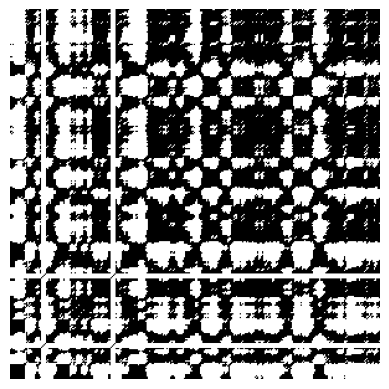

In [35]:
# plot_recurrence_plot(rr_intervals[0][:30])
os.chdir('/home/user/syx/code/ecg4hypertrophy')
signal = rr_intervals[0][:300]
ts = TimeSeries(signal, embedding_dimension=3, time_delay=1)

settings = Settings(ts,
                        analysis_type=Classic,
                            neighbourhood=FixedRadius(0.05),
                            similarity_measure=EuclideanMetric,
                            theiler_corrector=1)
computation = RPComputation.create(settings,
                                            verbose=False)
result = computation.run()
plt.imshow(result.recurrence_matrix, cmap='binary', origin='lower')
plt.axis('off')
plt.show()
# ImageGenerator.save_recurrence_plot(result.recurrence_matrix_reverse, 'recurrence_plot.png')


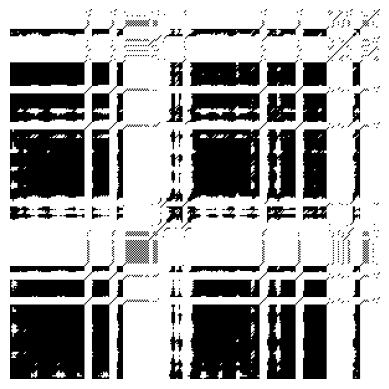

In [36]:
signal = rr_intervals[1][-300:]
ts = TimeSeries(signal, embedding_dimension=3, time_delay=1)

settings = Settings(ts,
                        analysis_type=Classic,
                            neighbourhood=FixedRadius(0.05),
                            similarity_measure=EuclideanMetric,
                            theiler_corrector=1)
computation = RPComputation.create(settings,
                                            verbose=False)
result = computation.run()
plt.imshow(result.recurrence_matrix, cmap='binary', origin='lower')
plt.axis('off')
plt.show()

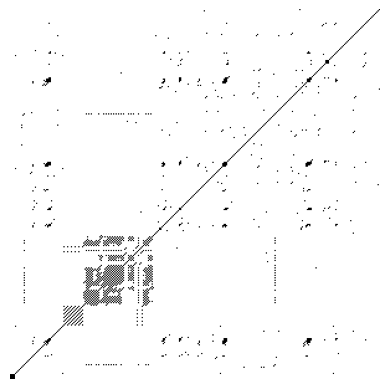

In [38]:
signal = rr_intervals[2][:300]
ts = TimeSeries(signal, embedding_dimension=3, time_delay=1)

settings = Settings(ts,
                        analysis_type=Classic,
                            neighbourhood=FixedRadius(0.05),
                            similarity_measure=EuclideanMetric,
                            theiler_corrector=1)
computation = RPComputation.create(settings,
                                            verbose=False)
result = computation.run()
plt.imshow(result.recurrence_matrix, cmap='binary', origin='lower')
plt.axis('off')
plt.show()

In [14]:
os.chdir('C:\\Users\\yxsun\\Desktop\\code\\pafdata')
sampling_frequency = 300
nsr_RRI = []
for i in range(1, 51, 2):
    record_name = f'p{i:02d}'
    annotation = wfdb.rdann(record_name, 'qrs')
    rr_intervals = np.diff(annotation.sample) / sampling_frequency
    n = 3
    for j in range(n):
        nsr_RRI.append(rr_intervals[31*j:31*(j+1)])
try:
    os.chdir('C:\\Users\\yxsun\\Desktop\\code')
    np.save('NSR_RR.npy', nsr_RRI)
    print("文件保存成功！")
except Exception as e:
    print(f"保存文件时出现错误: {e}")

文件保存成功！


In [15]:
sampling_frequency = 300
PreAF_RRI = []
for i in range(2, 51, 2):
    record_name = f'pafdata\\p{i:02d}'
    annotation = wfdb.rdann(record_name, 'qrs')
    rr_intervals = np.diff(annotation.sample) / sampling_frequency
    n = 3
    for j in range(n):
        start_index = len(rr_intervals) - 31 * (j + 1)
        end_index = len(rr_intervals) - 31 * j
        if start_index < 0:
            break
        PreAF_RRI.append(rr_intervals[start_index:end_index])
try:
    np.save('PreAF_RR.npy', PreAF_RRI)
    print("文件保存成功！")
except Exception as e:
    print(f"保存文件时出现错误: {e}")

文件保存成功！


In [ ]:
nsr_ecg = []
for i in range(1, 51, 2):
    record_name = f'paf-prediction-challenge-database-1.0.0/p{i:02d}'
    record = wfdb.rdrecord(record_name)
    signal_data1 = record.p_signal
    n = 3
    for j in range(n):
        nsr_ecg.append(nk.ecg_clean(signal_data1[128*j:128*(j+1), 0], sampling_rate=128, method="neurokit"))


    # record_name = f'p{i + 1:02d}'
    # record = wfdb.rdrecord(record_name)
    # signal_data3 = record.p_signal
    # ecg_signal.append(nk.ecg_clean(signal_data3[:, 0], sampling_rate=128, method="neurokit"))

    # record_name = f'p{i + 1:02d}c'
    # record = wfdb.rdrecord(record_name)
    # signal_data4 = record.p_signal
    # ecg_signal.append(nk.ecg_clean(signal_data4[:, 0], sampling_rate=128, method="neurokit"))

    # ecg.append(ecg_signal)
try:
    np.save('./pro_data/NSR.npy', nsr_ecg)
    print("文件保存成功！")
except Exception as e:
    print(f"保存文件时出现错误: {e}")
# signal_data = np.vstack((signal_data1, signal_data3, signal_data4))

文件保存成功！


In [33]:
preaf_ecg = []
for i in range(2, 51, 2):
    record_name = f'paf-prediction-challenge-database-1.0.0/p{i:02d}'
    record = wfdb.rdrecord(record_name)
    signal_data1 = record.p_signal
    n = 3
    for j in range(n):
        start_index = len(signal_data1) - 128 * (j + 1)
        end_index = len(signal_data1) - 128 * j
        if start_index < 0:
            break
        segment = signal_data1[start_index:end_index, 0]
        cleaned_segment = nk.ecg_clean(segment, sampling_rate=128, method="neurokit")
        preaf_ecg.append(cleaned_segment)


    # record_name = f'p{i + 1:02d}'
    # record = wfdb.rdrecord(record_name)
    # signal_data3 = record.p_signal
    # ecg_signal.append(nk.ecg_clean(signal_data3[:, 0], sampling_rate=128, method="neurokit"))

    # record_name = f'p{i + 1:02d}c'
    # record = wfdb.rdrecord(record_name)
    # signal_data4 = record.p_signal
    # ecg_signal.append(nk.ecg_clean(signal_data4[:, 0], sampling_rate=128, method="neurokit"))

    # ecg.append(ecg_signal)
try:
    np.save('./pro_data/PreAF.npy', preaf_ecg)
    print("文件保存成功！")
except Exception as e:
    print(f"保存文件时出现错误: {e}")
# signal_data = np.vstack((signal_data1, signal_data3, signal_data4))

文件保存成功！


In [ ]:
def remove_outliers_iqr(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    # 筛选出非异常值
    filtered_data = [x for x in data if lower_bound <= x <= upper_bound]
    return filtered_data

NSR = []
PreAF = []
os.chdir('/home/user/syx/code/ecg4hypertrophy')
data1 = np.load('pro_data/NSR_RR.npy')
data2 = np.load('pro_data/PreAF_RR.npy')
signal_len = 300
for i in range(2):
    for n in tqdm(range(len(data1))):
        if i == 0:
            data = data1
        else:
            data = data2
        os.chdir('/home/user/')
        time_series = TimeSeries(data[n],
                                embedding_dimension=3,
                                time_delay=2)
        settings = Settings(time_series,
                            analysis_type=Classic,
                            neighbourhood=FixedRadius(0.08),
                            similarity_measure=EuclideanMetric,
                            theiler_corrector=1)
        computation = RPComputation.create(settings,
                                                    verbose=False)
        result = computation.run()
        matrix = result.recurrence_matrix
        G = nx.from_numpy_array(matrix)
        degree_dict = dict(G.degree())
        average_degree = sum(degree_dict.values()) / len(G.nodes)
        avg_clustering = nx.average_clustering(G)
        try:
            # 计算图的直径
            diameter = nx.diameter(G)
        except nx.NetworkXError:
            pass
        if i == 0:   
            NSR.append(diameter)
        elif i == 1:
            PreAF.append(diameter)

data = [NSR, PreAF]
plt.boxplot(data, showfliers=False, positions = [0, 0.2], widths=0.05)
plt.xlim(-0.1, 0.4)
# plt.ylim(-0.1, 1.1)
plt.rcParams['font.sans-serif'] = ['AR PL UKai CN']
plt.xticks([0, 0.2], ['远离房颤', '接近房颤'])
plt.show()



  0%|          | 0/75 [00:00<?, ?it/s]


LogicError: clGetPlatformIDs failed: PLATFORM_NOT_FOUND_KHR

In [16]:
def remove_outliers_iqr(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    # 筛选出非异常值
    filtered_data = [x for x in data if lower_bound <= x <= upper_bound]
    return filtered_data

NSR = []
PreAF = []
os.chdir('/home/user/syx/code/ecg4hypertrophy')
data1 = np.load('pro_data/NSR_RR.npy')
data2 = np.load('pro_data/PreAF_RR.npy')
signal_len = 300
for i in range(2):
    for n in tqdm(range(len(data1))):
        if i == 0:
            data = data1
        else:
            data = data2
        time_series = TimeSeries(data[n],
                                embedding_dimension=3,
                                time_delay=2)
        settings = Settings(time_series,
                            analysis_type=Classic,
                            neighbourhood=FixedRadius(0.15),
                            similarity_measure=EuclideanMetric,
                            theiler_corrector=1)
        computation = RQAComputation.create(settings,
                                            verbose=False)
        result = computation.run()
        if i == 0:   
            NSR.append(result.recurrence_rate)
        elif i == 1:
            PreAF.append(result.entropy_diagonal_lines)

data = [NSR, PreAF]
plt.boxplot(data, showfliers=False, positions = [0, 0.2], widths=0.05)
plt.xlim(-0.1, 0.4)
# plt.ylim(-0.1, 1.1)
plt.rcParams['font.sans-serif'] = ['AR PL UKai CN']
plt.xticks([0, 0.2], ['远离房颤', '接近房颤'])
plt.show()


  0%|          | 0/75 [00:00<?, ?it/s]


LogicError: clGetPlatformIDs failed: PLATFORM_NOT_FOUND_KHR

In [5]:

def get_rqa_mea(file_path, threshold=0.05, measure='recurrence_rate'):
    rqa = []
    data = np.load(file_path)
    for i in range(len(data)):
        time_series = TimeSeries(data[i],
                                embedding_dimension=3,
                                time_delay=2)
        settings = Settings(time_series,
                            analysis_type=Classic,
                            neighbourhood=FixedRadius(threshold),
                            similarity_measure=EuclideanMetric,
                            theiler_corrector=1)
        computation = RQAComputation.create(settings,
                                            verbose=False)
        result = computation.run()
        if measure == 'recurrence_rate':
            rqa.append(result.recurrence_rate)
        elif measure == 'determinism':
            rqa.append(result.determinism)
        elif measure == 'entropy_diagonal_lines':
            rqa.append(result.entropy_diagonal_lines)
        elif measure == 'laminarity':
            rqa.append(result.laminarity)
    #     rqa.append([result.recurrence_rate, result.entropy_diagonal_lines, result.determinism, result.laminarity])
    return rqa

2 warnings generated.
/home/user/anaconda3/envs/syx_new/lib/python3.13/site-packages/pyopencl/__init__.py:519: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  lambda: self._prg.build(options_bytes, devices),
/home/user/anaconda3/envs/syx_new/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36882 (\N{CJK UNIFIED IDEOGRAPH-9012}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/anaconda3/envs/syx_new/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/anaconda3/envs/syx_new/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/anaconda3/envs/

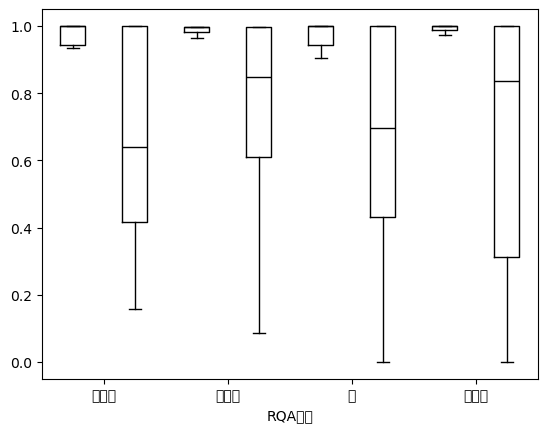

In [8]:
import matplotlib.pyplot as plt
import numpy as np
duliang = [(0.12, 'recurrence_rate'), (0.05, 'determinism'),(0.15, 'entropy_diagonal_lines') ,(0.05, 'laminarity')]
data_sets = []
for i in range(4):
    threshold, feature = duliang[i]
    nsr = get_rqa_mea('pro_data/NSR_RR.npy', threshold, feature)
    preaf = get_rqa_mea('pro_data/PreAF_RR.npy', threshold, feature)
    if i == 2:
        all_data = np.concatenate((nsr, preaf))
        min_val = np.min(all_data)
        max_val = np.max(all_data)

        # 对远离房颤的数据进行归一化
        nsr = (nsr - min_val) / (max_val - min_val)
        # 对接近房颤的数据进行归一化
        preaf = (preaf - min_val) / (max_val - min_val)
    data_sets.append([nsr, preaf])

labels = ['递归度', '确定度', '熵', '层状度']
positions = np.arange(len(labels)) * 2

fig, ax = plt.subplots()
for i, data in enumerate(data_sets):
    bp = ax.boxplot(data, positions=positions[i] + np.array([0, 1]), widths=0.4, showfliers=False)
    for element in ['boxes', 'whiskers', 'fliers','medians', 'caps']:
        plt.setp(bp[element], color='black')
    # bp['boxes'][0].set_facecolor('lightblue')
    # bp['boxes'][1].set_facecolor('lightcoral')

ax.set_xticks(positions + 0.5)
ax.set_xticklabels(labels)
ax.set_xlabel('RQA特征')
plt.show()

In [10]:
plt.rcParams['font.sans-serif'] = ['AR PL UKai CN']

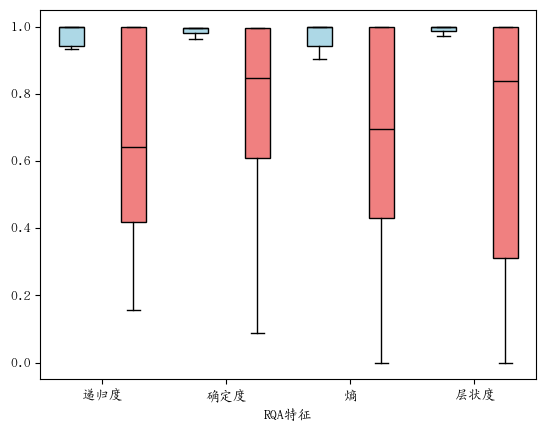

In [11]:
labels = ['递归度', '确定度', '熵', '层状度']
positions = np.arange(len(labels)) * 2

fig, ax = plt.subplots()
for i, data in enumerate(data_sets):
    bp = ax.boxplot(data, positions=positions[i] + np.array([0, 1]), widths=0.4, showfliers=False, patch_artist=True)
    for element in ['boxes', 'whiskers', 'fliers','medians', 'caps']:
        plt.setp(bp[element], color='black')
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')

ax.set_xticks(positions + 0.5)
ax.set_xticklabels(labels)
ax.set_xlabel('RQA特征')
plt.savefig('rqa_features.svg', format='svg', bbox_inches='tight')
plt.show()

In [45]:
def get_rqa(file_path, threshold=0.05):
    rqa = []
    data = np.load(file_path)
    for i in range(len(data)):
        time_series = TimeSeries(data[i],
                                embedding_dimension=3,
                                time_delay=2)
        settings = Settings(time_series,
                            analysis_type=Classic,
                            neighbourhood=FixedRadius(threshold),
                            similarity_measure=EuclideanMetric,
                            theiler_corrector=1)
        computation = RQAComputation.create(settings,
                                            verbose=False)
        result = computation.run()
        rqa.append(np.array([result.recurrence_rate, result.entropy_diagonal_lines, result.determinism, result.laminarity]))
    return rqa

In [96]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
os.chdir('C:\\Users\\yxsun\\Desktop\\code')
nsr_rqa = get_rqa('NSR_RR.npy', 0.07)
os.chdir('C:\\Users\\yxsun\\Desktop\\code')
preaf_rqa = get_rqa('PreAF_RR.npy', 0.07)
X = np.vstack((nsr_rqa, preaf_rqa))
y = np.hstack((np.zeros(75), np.ones(75)))
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建XGBoost分类器
clf = xgb.XGBClassifier()

# 训练模型
clf.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 评估模型性能
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy}")

# 打印分类报告
print("threshold 0.07 分类报告:")
print(classification_report(y_test, y_pred))

模型准确率: 0.7666666666666667
threshold 0.07 分类报告:
              precision    recall  f1-score   support

         0.0       0.74      0.88      0.80        16
         1.0       0.82      0.64      0.72        14

    accuracy                           0.77        30
   macro avg       0.78      0.76      0.76        30
weighted avg       0.77      0.77      0.76        30



In [48]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
threshold = np.arange(0.01, 0.21, 0.01)
acc = []
for i in tqdm(threshold):
    nsr_rqa = get_rqa('pro_data/NSR_RR.npy', i)
    preaf_rqa = get_rqa('pro_data/PreAF_RR.npy', i)
    X = np.vstack((nsr_rqa, preaf_rqa))
    y = np.hstack((np.zeros(75), np.ones(75)))
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 创建XGBoost分类器
    clf = xgb.XGBClassifier()

    # 训练模型
    clf.fit(X_train, y_train)

    # 在测试集上进行预测
    y_pred = clf.predict(X_test)

    # 评估模型性能
    accuracy = accuracy_score(y_test, y_pred)
    acc.append(accuracy)
    # print(f"模型准确率: {accuracy}")

    # # 打印分类报告
    # print("分类报告:")
    # print(classification_report(y_test, y_pred))

100%|██████████| 20/20 [02:19<00:00,  6.95s/it]


In [25]:

def get_rqa_mea(file_path, threshold=0.05, measure='recurrence_rate'):
    rqa = []
    data = np.load(file_path)
    for i in range(len(data)):
        time_series = TimeSeries(data[i],
                                embedding_dimension=3,
                                time_delay=2)
        settings = Settings(time_series,
                            analysis_type=Classic,
                            neighbourhood=FixedRadius(threshold),
                            similarity_measure=EuclideanMetric,
                            theiler_corrector=1)
        computation = RQAComputation.create(settings,
                                            verbose=False)
        result = computation.run()
        if measure == 'recurrence_rate':
            rqa.append(result.recurrence_rate)
        elif measure == 'determinism':
            rqa.append(result.determinism)
        elif measure == 'entropy_diagonal_lines':
            rqa.append(result.entropy_diagonal_lines)
        elif measure == 'laminarity':
            rqa.append(result.laminarity)
    #     rqa.append([result.recurrence_rate, result.entropy_diagonal_lines, result.determinism, result.laminarity])
    return rqa

100%|██████████| 20/20 [02:18<00:00,  6.95s/it]


Text(0, 0.5, 'recall')

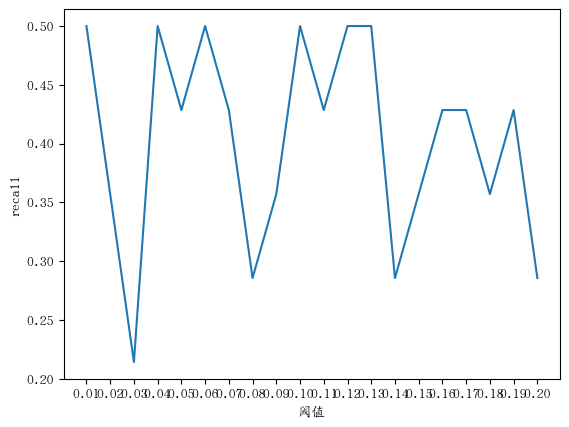

In [39]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, recall_score
import xgboost as xgb
threshold = np.arange(0.01, 0.21, 0.01)
acc = []
re = []
for i in tqdm(threshold):
    measure = 'laminarity'
    nsr_rqa = get_rqa_mea('pro_data/NSR_RR.npy', i, measure)
    preaf_rqa = get_rqa_mea('pro_data/PreAF_RR.npy', i, measure)
    X = np.hstack((nsr_rqa, preaf_rqa))
    X = X.reshape(-1, 1)
    y = np.hstack((np.zeros(75), np.ones(75)))
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 创建XGBoost分类器
    clf = xgb.XGBClassifier()

    # 训练模型
    clf.fit(X_train, y_train)

    # 在测试集上进行预测
    y_pred = clf.predict(X_test)

    # 评估模型性能
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    re.append(recall)
    acc.append(accuracy)
    # print(f"模型准确率: {accuracy}")

    # 打印分类报告
    # print("分类报告:")
    # print(classification_report(y_test, y_pred))
plt.plot(threshold, re)
plt.xticks(threshold)
plt.xlabel('阈值')
plt.ylabel('recall')

In [44]:
from sklearn.metrics import recall_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
measure = 'laminarity'
nsr_rqa = get_rqa_mea('pro_data/NSR_RR.npy', 0.06, measure)
preaf_rqa = get_rqa_mea('pro_data/PreAF_RR.npy', 0.06, measure)
X = np.hstack((nsr_rqa, preaf_rqa))
X = X.reshape(-1, 1)
y = np.hstack((np.zeros(75), np.ones(75)))
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建XGBoost分类器
clf = xgb.XGBClassifier()

# 训练模型
clf.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 评估模型性能
accuracy = accuracy_score(y_test, y_pred)
acc.append(accuracy)
sen = recall_score(y_test, y_pred)
print(f"模型准确率: {accuracy}")
print(f"灵敏度: {sen}")
# print(f"模型准确率: {accuracy}")

# 打印分类报告
print("分类报告:")
print(classification_report(y_test, y_pred))

模型准确率: 0.7333333333333333
灵敏度: 0.5
分类报告:
              precision    recall  f1-score   support

         0.0       0.68      0.94      0.79        16
         1.0       0.88      0.50      0.64        14

    accuracy                           0.73        30
   macro avg       0.78      0.72      0.71        30
weighted avg       0.77      0.73      0.72        30



In [ ]:
def get_rqa_all(file_path):
    rc = get_rqa_mea(file_path, 0.08, 'recurrence_rate')
    de = get_rqa_mea(file_path, 0.04, 'determinism')
    edl = get_rqa_mea(file_path, 0.07, 'entropy_diagonal_lines')
    la = get_rqa_mea(file_path, 0.06, 'laminarity')
    result = [list(item) for item in zip(rc, de, edl, la)]
    return result

In [47]:

nsr_rqa = get_rqa_all('pro_data/NSR_RR.npy')
preaf_rqa = get_rqa_all('pro_data/PreAF_RR.npy')

X = np.vstack((nsr_rqa, preaf_rqa))
y = np.hstack((np.zeros(75), np.ones(75)))
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建XGBoost分类器
clf = xgb.XGBClassifier()

# 训练模型
clf.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 评估模型性能
accuracy = accuracy_score(y_test, y_pred)
acc.append(accuracy)
# print(f"模型准确率: {accuracy}")

# 打印分类报告
print("分类报告:")
print(classification_report(y_test, y_pred))

分类报告:
              precision    recall  f1-score   support

         0.0       0.71      0.75      0.73        16
         1.0       0.69      0.64      0.67        14

    accuracy                           0.70        30
   macro avg       0.70      0.70      0.70        30
weighted avg       0.70      0.70      0.70        30



In [ ]:
os.chdir('C:\\Users\\yxsun\\Desktop\\code')
measure = 'recurrence_rate'
nsr_rqa = get_rqa_mea('NSR_RR.npy', 0.08, measure)
os.chdir('C:\\Users\\yxsun\\Desktop\\code')
preaf_rqa = get_rqa_mea('PreAF_RR.npy', 0.08, measure)

X = np.hstack((nsr_rqa, preaf_rqa))
X = X.reshape(-1, 1)
y = np.hstack((np.zeros(75), np.ones(75)))
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建XGBoost分类器
clf = xgb.XGBClassifier()

# 训练模型
clf.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = clf.predict(X_test)

# 评估模型性能
accuracy = accuracy_score(y_test, y_pred)
acc.append(accuracy)
# print(f"模型准确率: {accuracy}")

# 打印分类报告
print("分类报告:")
print(classification_report(y_test, y_pred))